# **Analyse des résultats**

## **Requirement**

Avoir entrainé un modèle pour générer __*best_model_metrics_per_class.csv*__


**Librairies**

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

## **0. Loading des résultats**

In [89]:
df_log1 = pd.read_csv("training_log.csv")
df_log2 = pd.read_csv("training_log.csv")

df_confusion_matrix1 = pd.read_csv("best_model_confusion_matrix_bis.csv")
df_confusion_matrix2 = pd.read_csv("best_model_confusion_matrix_bis.csv")

df_metrics_per_class1 = pd.read_csv("best_model_metrics_per_class_bis.csv")
df_metrics_per_class2 = pd.read_csv("best_model_metrics_per_class_bis.csv")

## **1. Résultats macro**

### **1.1 Loss**

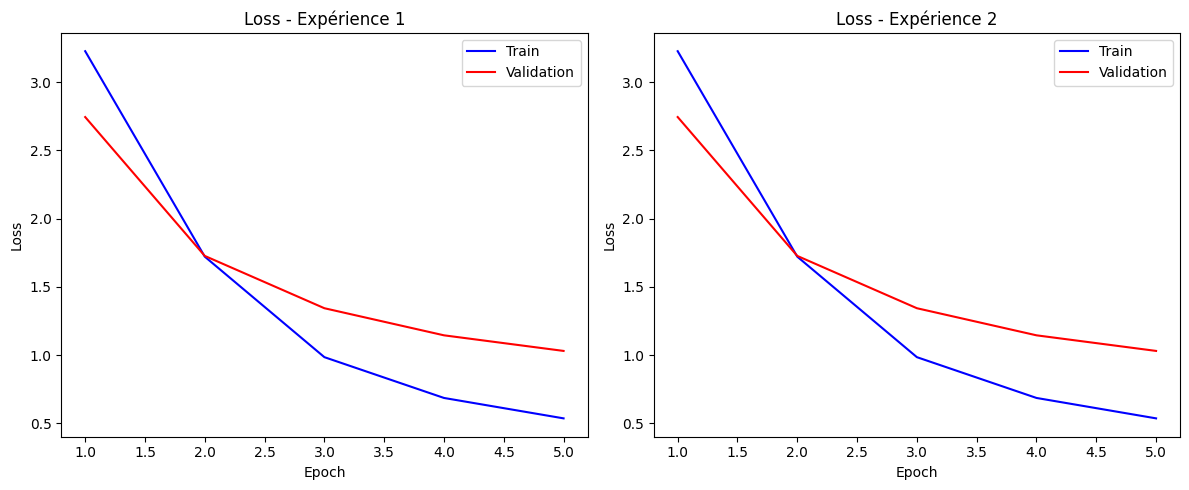

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Log 1
axes[0].plot(df_log1["epoch"], df_log1["train_loss"], color="blue", label="Train")
axes[0].plot(df_log1["epoch"], df_log1["val_loss"], color="red", label="Validation")
axes[0].set_title("Loss - Expérience 1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


# Log 2
axes[1].plot(df_log2["epoch"], df_log2["train_loss"], color="blue", label="Train")
axes[1].plot(df_log2["epoch"], df_log2["val_loss"], color="red", label="Validation")
axes[1].set_title("Loss - Expérience 2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()


plt.tight_layout()
plt.show()

### **1.2 F1-macro**

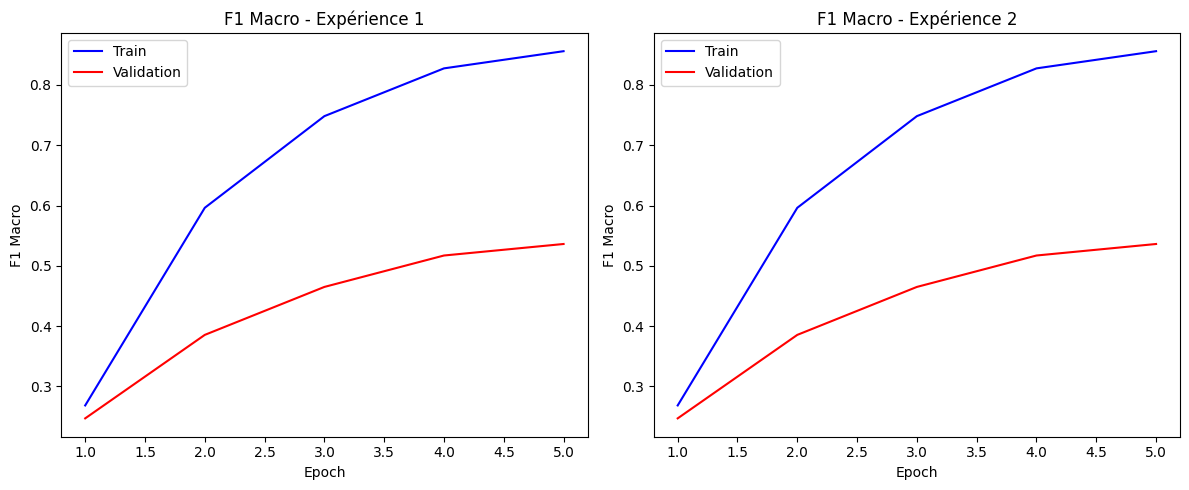

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Expérience 1
axes[0].plot(df_log1["epoch"], df_log1["train_f1_macro"], color="blue", label="Train")
axes[0].plot(df_log1["epoch"], df_log1["val_f1_macro"], color="red", label="Validation")
axes[0].set_title("F1 Macro - Expérience 1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("F1 Macro")
axes[0].legend()


# Expérience 2
axes[1].plot(df_log2["epoch"], df_log2["train_f1_macro"], color="blue", label="Train")
axes[1].plot(df_log2["epoch"], df_log2["val_f1_macro"], color="red", label="Validation")
axes[1].set_title("F1 Macro - Expérience 2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Macro")
axes[1].legend()


plt.tight_layout()
plt.show()

## **1.3 Accuracy**

KeyError: 'val_acc'

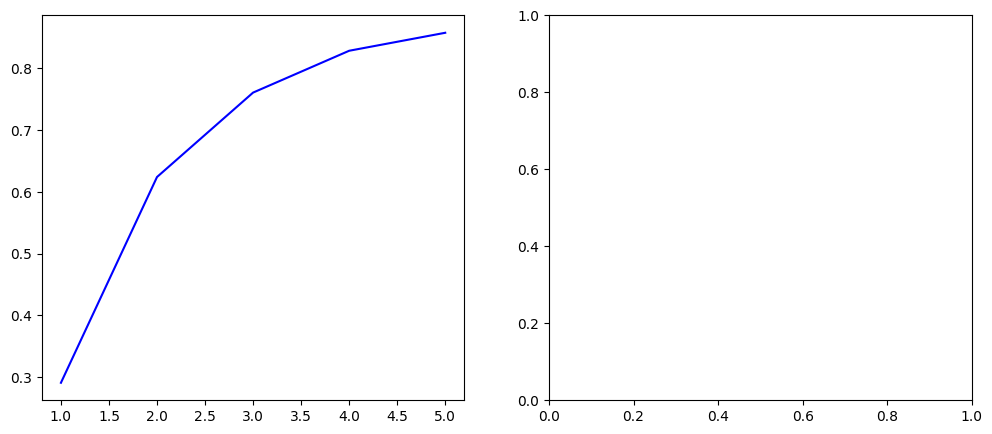

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Expérience 1
axes[0].plot(df_log1["epoch"], df_log1["train_acc"], color="blue", label="Train")
axes[0].plot(df_log1["epoch"], df_log1["val_acc"], color="red", label="Validation")
axes[0].set_title("Accuracy - Expérience 1")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()


# Expérience 2
axes[1].plot(df_log2["epoch"], df_log2["train_acc"], color="blue", label="Train")
axes[1].plot(df_log2["epoch"], df_log2["val_acc"], color="red", label="Validation")
axes[1].set_title("Accuracy - Expérience 2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **2. Résultats par classe**

### **2.1 Confusion matrix**

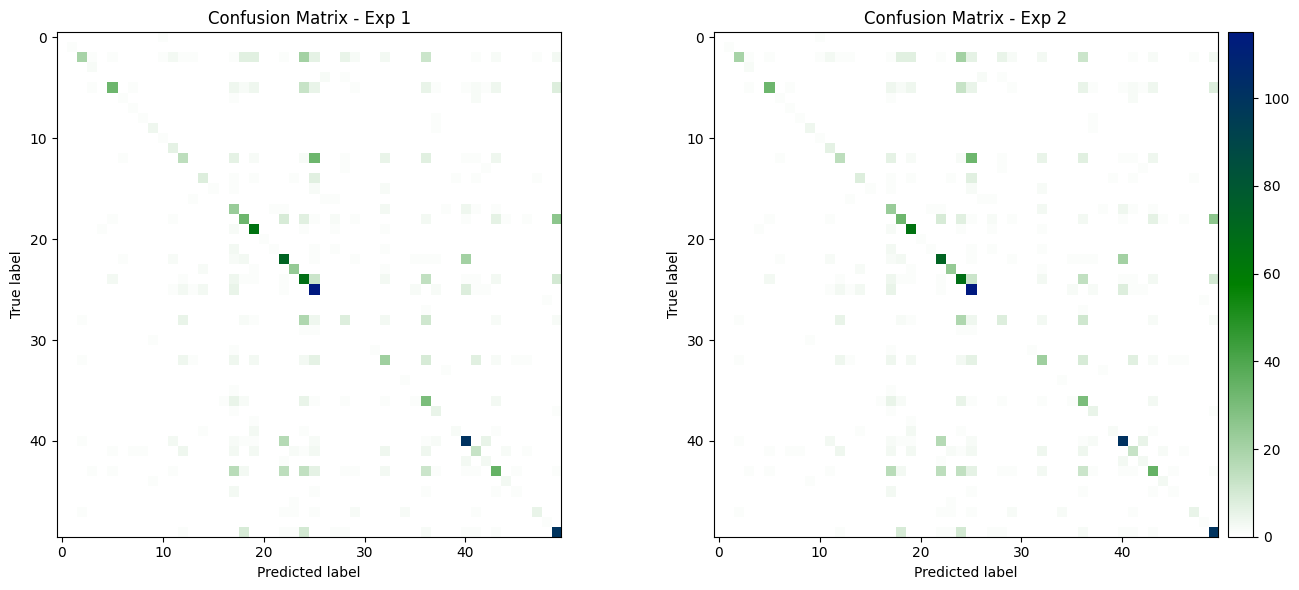

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

cm1 = df_confusion_matrix1.values
cm2 = df_confusion_matrix2.values

# Échelle commune
vmax = max(cm1.max(), cm2.max())

# Palette dégradée : bleu foncé -> vert -> blanc
colors = [ (1,1,1), (0,0.5,0), (0,0.1,0.5)]  # RGB tuples
cmap = LinearSegmentedColormap.from_list("custom_blue_green_white", colors, N=256)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Graphe 1 ---
im1 = axes[0].imshow(cm1, interpolation='nearest', vmin=0, vmax=vmax, cmap=cmap)
axes[0].set_title("Confusion Matrix - Exp 1")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

# --- Graphe 2 ---
im2 = axes[1].imshow(cm2, interpolation='nearest', vmin=0, vmax=vmax, cmap=cmap)
axes[1].set_title("Confusion Matrix - Exp 2")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

# --- Colorbar à droite ---
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im2, cax=cax)

plt.tight_layout()
plt.show()

## **2.2 F1-score par classe**

**Rappel du nombre d'image par classe**

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

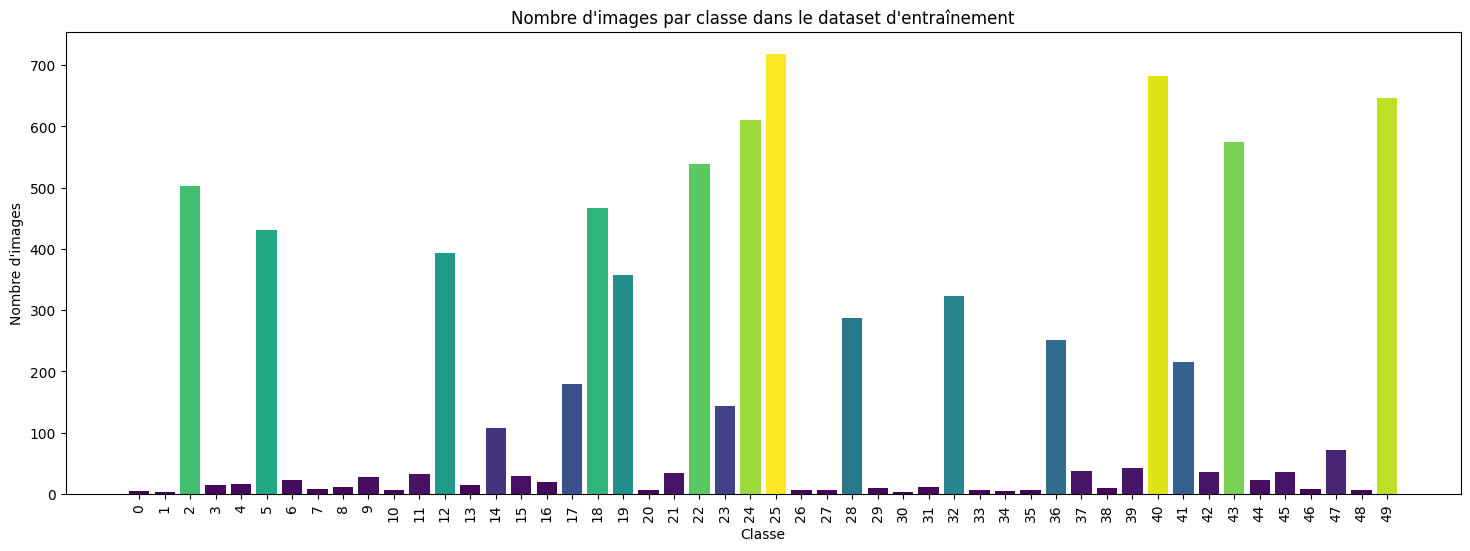

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

# Construire le chemin relatif
csv_path = os.path.join("..","data", "train_corrected.csv")
df = pd.read_csv(csv_path)

# Compter le nombre d'images par classe
class_counts = df['label'].value_counts().sort_index()

# Normaliser pour la couleur
norm = class_counts / class_counts.max()
colors = cm.viridis(norm)  # dégradé bleu foncé -> vert -> jaune clair

plt.figure(figsize=(18,6))
plt.bar(class_counts.index, class_counts.values, color=colors)
plt.xticks(class_counts.index, rotation=90)
plt.ylabel("Nombre d'images")
plt.xlabel("Classe")
plt.title("Nombre d'images par classe dans le dataset d'entraînement")

# Optionnel : ajouter une légende avec gradient
sm = cm.ScalarMappable(cmap='viridis')
sm.set_array(class_counts.values)
cbar = plt.colorbar(sm)
cbar.set_label("Nombre d'images (échelle couleur)")

plt.show()

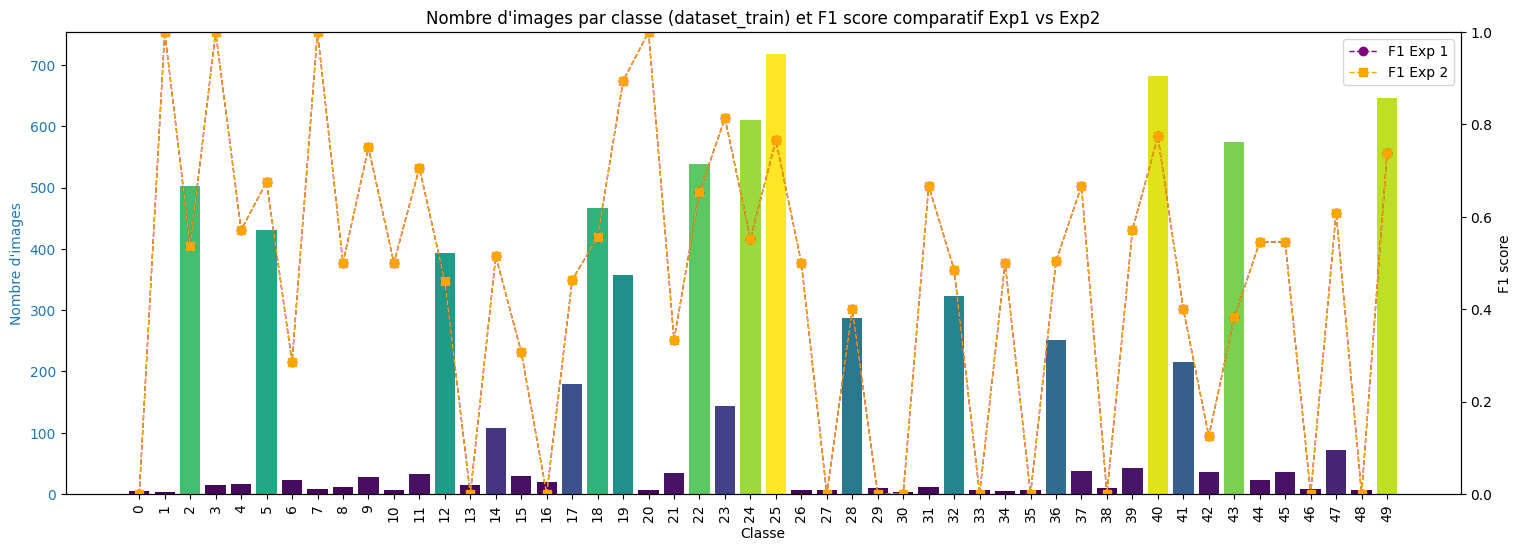

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import numpy as np

# --- Charger le CSV du dataset pour le nombre d'images ---
csv_path = os.path.join("..","data", "train_corrected.csv")
df = pd.read_csv(csv_path)

# Compter le nombre d'images par classe
class_counts = df['label'].value_counts().sort_index()



df_metrics1 = df_metrics_per_class1.sort_values("class")
df_metrics2 = df_metrics_per_class2.sort_values("class")

f1_exp1 = df_metrics1['f1_score'].values
f1_exp2 = df_metrics2['f1_score'].values

classes = class_counts.index

# --- Palette couleur pour les barres selon nombre d'images ---
norm = class_counts / class_counts.max()
colors = cm.viridis(norm)

# --- Création du graphique ---
fig, ax1 = plt.subplots(figsize=(18,6))

# Barres : nombre d'images par classe
bars = ax1.bar(classes, class_counts.values, color=colors, label='Nombre d\'images')
ax1.set_xlabel("Classe")
ax1.set_ylabel("Nombre d'images", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(classes)
ax1.set_xticklabels(classes, rotation=90)

# Axe secondaire pour F1 scores
ax2 = ax1.twinx()
ax2.plot(classes, f1_exp1, color='purple', marker='o', linestyle='--', linewidth=1, label='F1 Exp 1')
ax2.plot(classes, f1_exp2, color='orange', marker='s', linestyle='--', linewidth=1, label='F1 Exp 2')
ax2.set_ylabel("F1 score", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 1)  # F1 entre 0 et 1

# Légende combinée
lines_labels = [ax2.get_legend_handles_labels()]
lines, labels = [], []
for lh, lb in lines_labels:
    lines += lh
    labels += lb
ax2.legend(lines, labels, loc='upper right')

plt.title("Nombre d'images par classe (dataset_train) et F1 score comparatif Exp1 vs Exp2")
plt.show()

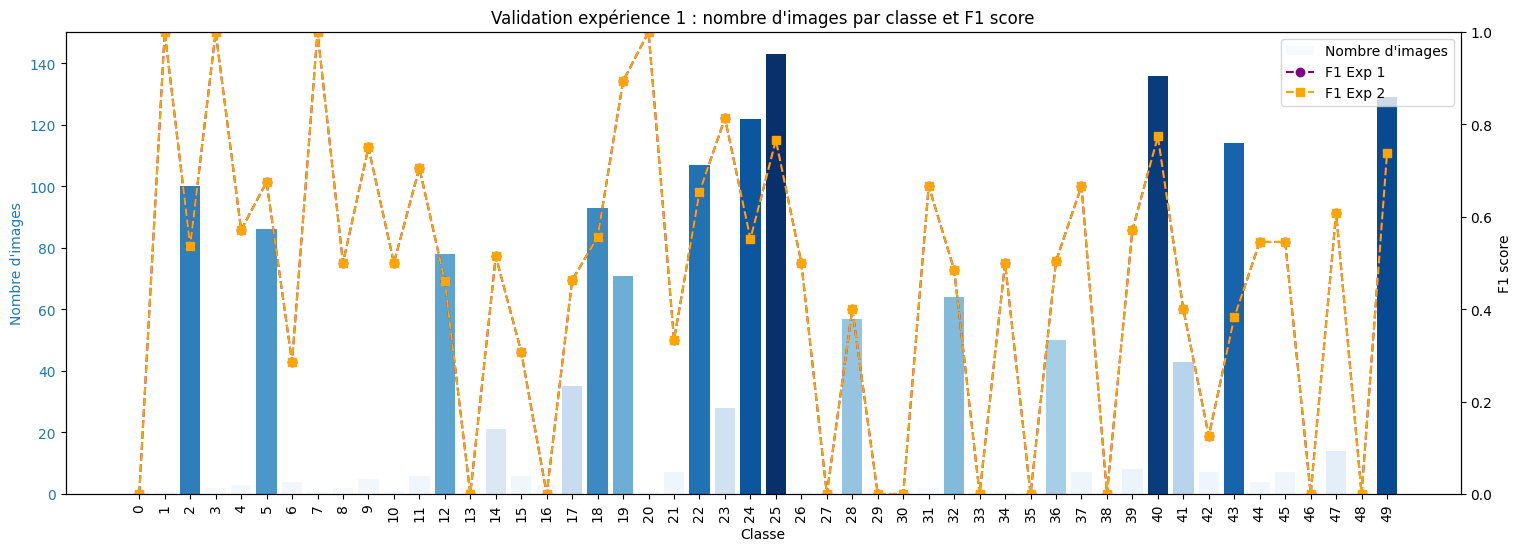

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import os
import csv



# Charger le CSV pour plotting
df_val_counts = pd.read_csv("val_class_counts.csv")
df_val_counts = df_val_counts.sort_values("class")
classes = df_val_counts['class'].values
num_images = df_val_counts['num_images'].values

# --- Étape 2 : récupérer les F1 scores pour deux expériences ---
df_metrics1 = df_metrics_per_class1.sort_values("class")
df_metrics2 = df_metrics_per_class2.sort_values("class")

f1_exp1 = df_metrics1['f1_score'].values
f1_exp2 = df_metrics2['f1_score'].values


# --- Étape 3 : palette couleur pour le nombre d'images ---
norm = num_images / num_images.max()
colors = cm.Blues(norm)  # dégradé bleu foncé -> clair selon nombre d'images

# --- Étape 4 : création du graphique ---
fig, ax1 = plt.subplots(figsize=(18,6))

# Barres : nombre d'images par classe
bars = ax1.bar(classes, num_images, color=colors, label="Nombre d'images")
ax1.set_xlabel("Classe")
ax1.set_ylabel("Nombre d'images", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(classes)
ax1.set_xticklabels(classes, rotation=90)

# Axe secondaire pour F1 scores
ax2 = ax1.twinx()
ax2.plot(classes, f1_exp1, color='purple', marker='o', linestyle='--', linewidth=1.5, label='F1 Exp 1')
ax2.plot(classes, f1_exp2, color='orange', marker='s', linestyle='--', linewidth=1.5, label='F1 Exp 2')
ax2.set_ylabel("F1 score", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0,1)

# Légende combinée
lines_labels = [ax1.get_legend_handles_labels(), ax2.get_legend_handles_labels()]
lines, labels = [], []
for lh, lb in lines_labels:
    lines += lh
    labels += lb
ax2.legend(lines, labels, loc='upper right')

plt.title("Validation expérience 1 : nombre d'images par classe et F1 score")
plt.show()

**Comparason des autres metriques**

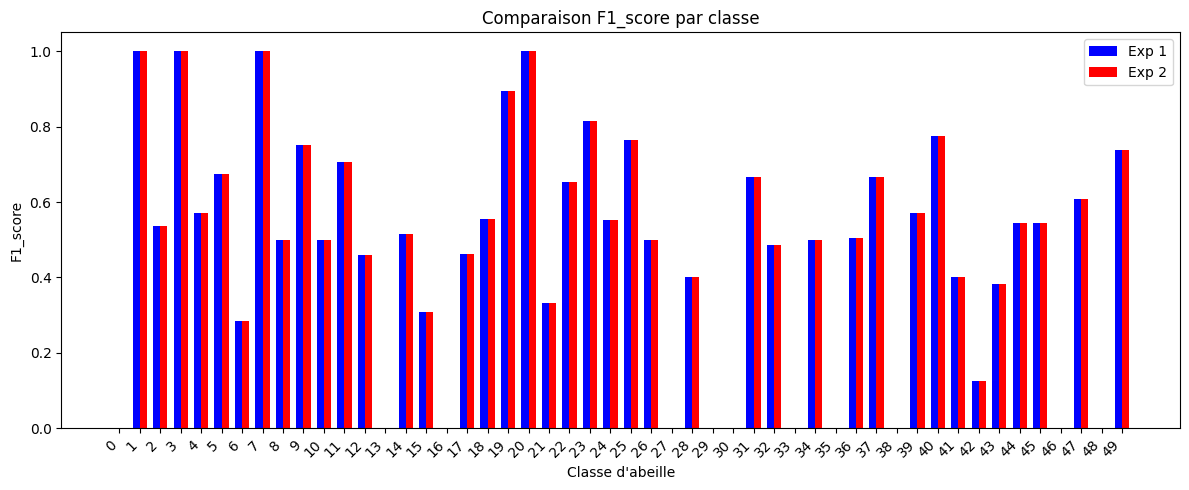

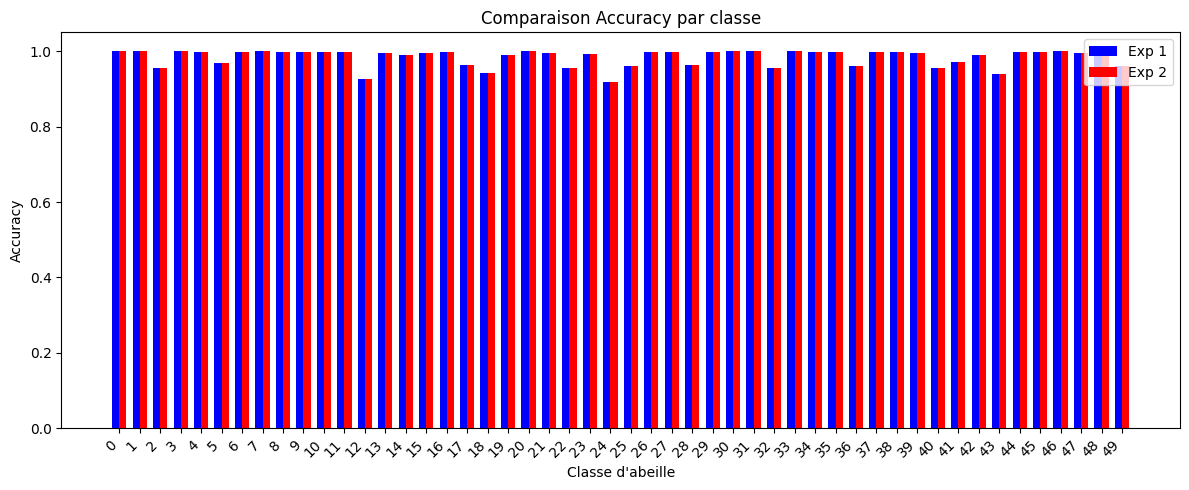

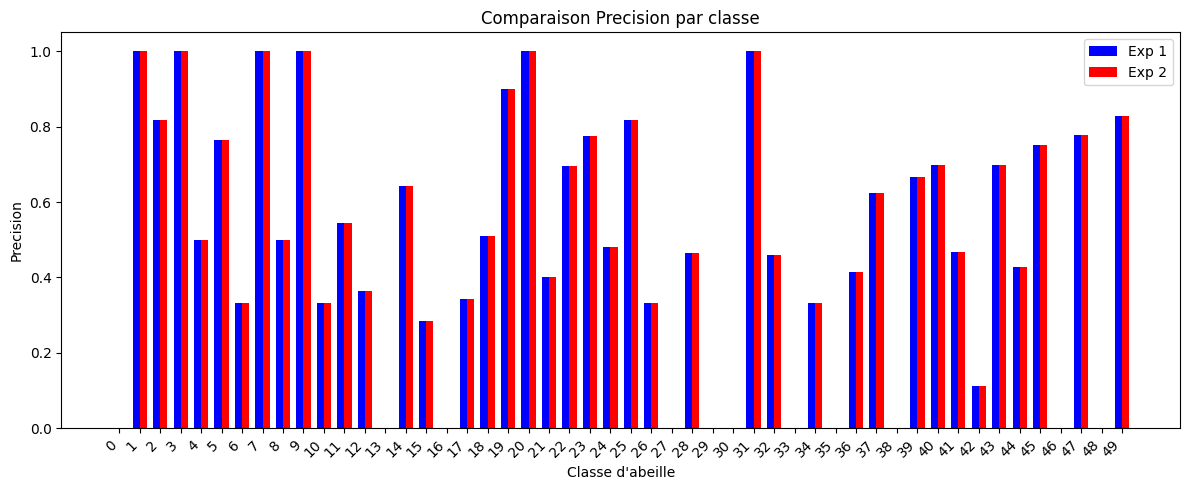

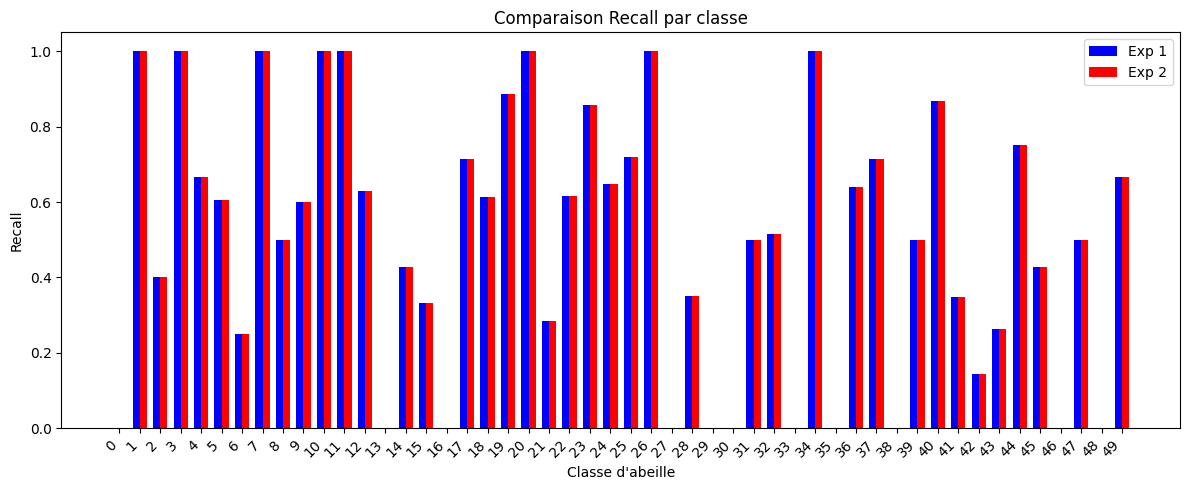

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



classes = df_metrics_per_class1['class']  # ou juste df_metrics1['class'] si présente

metrics = ["f1_score","accuracy", "precision", "recall"]

for metric in metrics:
    values1 = df_metrics_per_class1[metric].values
    values2 = df_metrics_per_class2[metric].values

    x = np.arange(len(classes))
    width = 0.35  # largeur des barres

    fig, ax = plt.subplots(figsize=(12,5))
    ax.bar(x - width/2, values1, width, label="Exp 1", color='blue')
    ax.bar(x + width/2, values2, width, label="Exp 2", color='red')

    ax.set_xlabel("Classe d'abeille")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Comparaison {metric.capitalize()} par classe")
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylim(0,1.05)  # toutes les métriques sont entre 0 et 1

    ax.legend()
    plt.tight_layout()
    plt.show()